In [55]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\dilara\Desktop\Hane halkı bilişim tüik\ferthane\bütünveriler.csv")
df.head()

C:\Users\dilara\AppData\Local\Temp\ipykernel_20664\2756381514.py:2: DtypeWarning: Columns (0: fert durum, 1: istatistiki bölge birimleri sınıflaması(Düzey 1), 2: fert ağırlık katsayısı, 3: hane ağırlık katsayısı, 4: istatistiki bölge birimleri sınıflaması (düzey 1), 5: hanede var olan bilişim cihazları açıklaması, 6: hanefaktor, 7: eticaret tür açıklama, 8: doğduğu ülke kodu, 9: uyruk ülke kodu) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"C:\Users\dilara\Desktop\Hane halkı bilişim tüik\ferthane\bütünveriler.csv")


,Unnamed: 0,referans yıl,bülten no,fert no,fert cevap durumu,fert durum,cevapsız fert,cevaplayan fert,cevaplayan fert no,yaş,...,ürün güvenliği hakkında arama,yapay zeka kullanımı,yapay zeka özel amaç kullanımı,yapay zeka iş için kullanımı,yapay zeka eğitim için kullanımı,yapay zeka kullanmama nedeni,eticaretten alınan fiziksel mal,eticaret sağlık güven sorunu,kvkk reklam takip endişesi,hanehalkı adresinin kır veya kent olma durumu
0,0,2015,10011,1,1.0,CEVAPLI FERT,NaN,1.0,NaN,58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2015,10012,3,1.0,CEVAPLI FERT,NaN,1.0,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2015,10012,2,1.0,CEVAPLI FERT,NaN,1.0,NaN,48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2015,10012,1,1.0,CEVAPLI FERT,NaN,1.0,NaN,54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2015,10013,3,1.0,CEVAPLI FERT,NaN,1.0,NaN,39,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
digital_vars = [

    # Dijital erişim
    "en son internet ne zaman kullanıldı",

    # Kullanım yoğunluğu
    "internet kullanım sıklığı",

    # Bilgisayar kullanımı
    "bilgisayar son kullanım zamanı",

    # Sosyal dijital katılım
    "sosyal medya kullanımı",

    # Dijital iletişim
    "eposta kullanımı",

    # Bilgi toplumu davranışları
    "internet araması",
    "online haber okuma",
    "ürün hizmet arama",

    # Dijital vatandaşlık
    "edevlet hakkında bilgi",

    # Dijital ekonomi
    "eticaret kullanımı"
]

In [57]:
import numpy as np
missing_codes = [97, 98, 99, 999]

for col in digital_vars:
    df[col] = df[col].replace(missing_codes, np.nan)

In [58]:

# ---------------------------------------------------
# İNTERNET KULLANIMI
# ---------------------------------------------------
# sadece aktif kullanım = 1

df["internet_binary"] = np.where(
    df["en son internet ne zaman kullanıldı"] == 1,
    1,
    0
)

# ---------------------------------------------------
# BİLGİSAYAR KULLANIMI
# ---------------------------------------------------

df["computer_binary"] = np.where(
    df["bilgisayar son kullanım zamanı"] == 1,
    1,
    0
)

# ---------------------------------------------------
# SOSYAL MEDYA
# ---------------------------------------------------

df["sosyal medya kullanımı"] = np.where(
    df["sosyal medya kullanımı"] == 1,
    1,
    0
)

# ---------------------------------------------------
# EPOSTA
# ---------------------------------------------------

df["eposta kullanımı"] = np.where(
    df["eposta kullanımı"] == 1,
    1,
    0
)

# ---------------------------------------------------
# İNTERNET ARAMASI
# ---------------------------------------------------

df["internet araması"] = np.where(
    df["internet araması"] == 1,
    1,
    0
)

# ---------------------------------------------------
# ONLINE HABER
# ---------------------------------------------------

df["online haber okuma"] = np.where(
    df["online haber okuma"] == 1,
    1,
    0
)

# ---------------------------------------------------
# ÜRÜN HİZMET ARAMA
# ---------------------------------------------------

df["ürün hizmet arama"] = np.where(
    df["ürün hizmet arama"] == 1,
    1,
    0
)

# ---------------------------------------------------
# E-DEVLET
# ---------------------------------------------------

df["edevlet hakkında bilgi"] = np.where(
    df["edevlet hakkında bilgi"] == 1,
    1,
    0
)

# ---------------------------------------------------
# E-TİCARET
# ---------------------------------------------------

df["eticaret kullanımı"] = np.where(
    df["eticaret kullanımı"] == 1,
    1,
    0
)


C:\Users\dilara\AppData\Local\Temp\ipykernel_20664\3164620693.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["internet_binary"] = np.where(
C:\Users\dilara\AppData\Local\Temp\ipykernel_20664\3164620693.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["computer_binary"] = np.where(


In [59]:
#skor
internet_use_map = {

    1: 1.00,   # son 3 ay
    2: 0.75,   # son 1 yıl
    3: 0.50,   # 1 yıldan uzun
    4: 0       # hiç kullanmadı
}

df["en son internet ne zaman kullanıldı"] = (
    df["en son internet ne zaman kullanıldı"]
    .map(internet_use_map)
)


In [60]:
frequency_map = {

    1: 1.00,   # her gün
    2: 0.75,
    3: 0.50,
    4: 0.25,
    5: 0
}

df["internet kullanım sıklığı"] = (
    df["internet kullanım sıklığı"]
    .map(frequency_map)
)

In [61]:
#bilgisayar kullanımı
computer_use_map = {

    1: 1.00,
    2: 0.75,
    3: 0.50,
    4: 0
}

df["bilgisayar son kullanım zamanı"] = (
    df["bilgisayar son kullanım zamanı"]
    .map(computer_use_map)
)


In [62]:
#dijital endks
df["digitalization_index"] = (
    df[digital_vars]
    .mean(axis=1)
)


C:\Users\dilara\AppData\Local\Temp\ipykernel_20664\77620208.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["digitalization_index"] = (


In [63]:
#dijitalleşme seviyesi
df["digitalization_level"] = pd.cut(

    df["digitalization_index"],

    bins=[0, 0.33, 0.66, 1],

    labels=[
        "Düşük",
        "Orta",
        "Yüksek"
    ]
)

C:\Users\dilara\AppData\Local\Temp\ipykernel_20664\367746112.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["digitalization_level"] = pd.cut(


In [64]:
print("\nDijitalleşme Endeksi Özeti\n")

print(
    df["digitalization_index"]
    .describe()
)


Dijitalleşme Endeksi Özeti

count    381809.000000
mean          0.382844
std           0.370164
min           0.000000
25%           0.000000
50%           0.375000
75%           0.750000
max           1.000000
Name: digitalization_index, dtype: float64


In [65]:
region_column = "istatistiki bölge birimleri sınıflaması(Düzey 1)"

regional_index = (

    df
    .groupby(region_column)["digitalization_index"]
    .mean()
    .sort_values(ascending=False)
)

print("\nBölgelere Göre Dijitalleşme\n")

print(regional_index)



Bölgelere Göre Dijitalleşme

istatistiki bölge birimleri sınıflaması(Düzey 1)
TR1    0.337257
TR5    0.269811
TR4    0.258097
TR3    0.254835
TR2    0.250153
TR6    0.230559
TR7    0.226692
TR8    0.222248
TR9    0.210629
TRB    0.143030
TRC    0.139271
TRA    0.130135
Name: digitalization_index, dtype: float64


In [66]:

yearly_index = (

    df
    .groupby("referans yıl")["digitalization_index"]
    .mean()
)

print("\nYıllara Göre Dijitalleşme\n")

print(yearly_index)


Yıllara Göre Dijitalleşme

referans yıl
2015    0.204899
2016    0.203630
2017    0.256142
2018    0.392952
2019    0.297962
2020    0.330225
2021    0.534720
2022    0.548407
2023    0.583957
2024    0.580449
2025    0.607894
Name: digitalization_index, dtype: float64


Endeks oluşturulurken tüm yıllarda ortak bulunan değişkenler tercih edilmiştir. Böylece yıllar arası karşılaştırılabilir ve tutarlı bir yapı kurulmuştur.

Endeks içerisinde internet kullanımı, bilgisayar kullanımı, sosyal medya kullanımı, e-posta kullanımı, internet araması, online haber okuma, ürün/hizmet araştırması, e-devlet kullanımı ve e-ticaret kullanımı gibi dijital faaliyetleri temsil eden değişkenler kullanılmıştır.

Veri setindeki değişkenler binary (0-1) yapıya dönüştürülmüştür. Dijital faaliyeti gerçekleştiren bireyler “1”, gerçekleştirmeyen bireyler ise “0” olarak kodlanmıştır. Daha sonra bireylerin dijital faaliyet puanları toplanarak 0 ile 1 arasında standartlaştırılmış bir dijitalleşme endeksi elde edilmiştir.

Analiz sonuçlarına göre Türkiye’de dijitalleşme düzeyi yıllar içerisinde artış göstermektedir. Özellikle 2020 sonrası dönemde dijitalleşme hızlanmıştır. Bunun temel nedenleri arasında pandemi sonrası uzaktan eğitim, e-devlet hizmetleri, mobil internet ve e-ticaret kullanımındaki artış yer almaktadır.

Bölgesel sonuçlar incelendiğinde İstanbul ve batı bölgelerinde dijitalleşme düzeyinin daha yüksek olduğu, Doğu ve Güneydoğu Anadolu bölgelerinde ise daha düşük seviyelerde kaldığı görülmektedir. Bu durum Türkiye’de bölgesel dijital eşitsizliklerin varlığını göstermektedir.

In [67]:
# ---------------------------------------------------
# GELİRİ 5'Lİ GRUBA DÖNÜŞTÜR
# ---------------------------------------------------

# Sayısal hale çevir

df["hane gelir aylık"] = pd.to_numeric(
    df["hane gelir aylık"],
    errors="coerce"
)

# Eksikleri kaldır

income_df = df[
    df["hane gelir aylık"].notna()
].copy()

# Quantile tabanlı 5'li grup oluştur

income_df["income_5_group"] = pd.qcut(

    income_df["hane gelir aylık"],

    q=5,

    labels=[1, 2, 3, 4, 5]
)

# Ana veri setine aktar

df.loc[
    income_df.index,
    "income_5_group"
] = income_df["income_5_group"]

# Sayıya çevir

df["income_5_group"] = pd.to_numeric(
    df["income_5_group"]
)

# Kontrol

print(
    df["income_5_group"]
    .value_counts()
)

income_5_group
2.0    56708
1.0    48649
4.0    46660
5.0    44298
3.0    31129
Name: count, dtype: int64


C:\Users\dilara\AppData\Local\Temp\ipykernel_20664\4232172973.py:31: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.loc[


In [68]:
# ---------------------------------------------------
# REGRESYON VERİ SETİ
# ---------------------------------------------------

model_vars = [

    "digitalization_index",

    "yaş",

    "cinsiyet",

    "eğitim",

    "çalışma durumu",

    "income_5_group",

    "istatistiki bölge birimleri sınıflaması(Düzey 1)"
]

model_df = df[model_vars].copy()

# Eksikleri temizle

model_df = model_df.dropna()

# Kontrol

print(model_df.head())

print("\nBoyut:")
print(model_df.shape)


   digitalization_index  yaş  cinsiyet  eğitim  çalışma durumu  \
0              0.277778   58         1     1.0             3.0   
1              0.900000   20         1     3.0             3.0   
2              0.575000   48         2     1.0             3.0   
3              0.500000   54         1     3.0             3.0   
4              0.305556   39         2     1.0             3.0   

   income_5_group istatistiki bölge birimleri sınıflaması(Düzey 1)  
0             1.0                                              TR1  
1             4.0                                              TR1  
2             4.0                                              TR1  
3             4.0                                              TR1  
4             2.0                                              TR1  

Boyut:
(77394, 7)


In [69]:
# ---------------------------------------------------
# DUMMY DEĞİŞKENLER
# ---------------------------------------------------

model_df = pd.get_dummies(

    model_df,

    columns=[

        "cinsiyet",
        "eğitim",
        "çalışma durumu",
        "istatistiki bölge birimleri sınıflaması(Düzey 1)"
    ],

    drop_first=True
)

# Booleanları integer yap

model_df = model_df.astype(int, errors="ignore")

# Kontrol

print(model_df.head())

print("\nYeni Boyut:")
print(model_df.shape)


   digitalization_index  yaş  income_5_group  cinsiyet_2  eğitim_1.0  \
0                     0   58               1           0           1   
1                     0   20               4           0           0   
2                     0   48               4           1           1   
3                     0   54               4           0           0   
4                     0   39               2           1           1   

   eğitim_2.0  eğitim_3.0  eğitim_4.0  eğitim_5.0  eğitim_6.0  ...  \
0           0           0           0           0           0  ...   
1           0           1           0           0           0  ...   
2           0           0           0           0           0  ...   
3           0           1           0           0           0  ...   
4           0           0           0           0           0  ...   

   istatistiki bölge birimleri sınıflaması(Düzey 1)_TR3  \
0                                                  0      
1                           

In [70]:
# ---------------------------------------------------
# EĞİTİM KATEGORİLERİ
# ---------------------------------------------------
# TÜİK kodlarını ortak kategoriye dönüştürme

education_map = {

    # İlkokul ve altı
    0: "İlkokul ve Altı",
    1: "İlkokul ve Altı",
    2: "İlkokul ve Altı",

    # Alternatif kodlar
    "1": "İlkokul ve Altı",
    "2": "İlkokul ve Altı",

    # Ortaokul - Lise
    3: "Ortaokul-Lise",
    4: "Ortaokul-Lise",

    # Alternatif kodlar
    "3": "Ortaokul-Lise",
    "4": "Ortaokul-Lise",

    # Üniversite
    511: "Üniversite",
    512: "Üniversite",

    # Eski sistem
    5: "Üniversite",
    6: "Üniversite",

    # Üniversite üstü
    52: "Üniversite Üstü",
    53: "Üniversite Üstü",

    # Eski sistem
    7: "Üniversite Üstü"
}

df["education_category"] = (
    df["eğitim"]
    .map(education_map)
)

# ---------------------------------------------------
# YAŞ KATEGORİLERİ
# ---------------------------------------------------

df["age_category"] = pd.cut(

    df["yaş"],

    bins=[0, 15, 30, 45, 60, 120],

    labels=[
        "0-15",
        "16-30",
        "31-45",
        "46-60",
        "60+"
    ]
)

# ---------------------------------------------------
# KONTROL
# ---------------------------------------------------

print("\nEğitim Kategorileri\n")

print(
    df["education_category"]
    .value_counts(dropna=False)
)

print("\nYaş Kategorileri\n")

print(
    df["age_category"]
    .value_counts(dropna=False)
)


Eğitim Kategorileri

education_category
İlkokul ve Altı    139674
Ortaokul-Lise      111657
NaN                 89907
Üniversite          35562
Üniversite Üstü      5009
Name: count, dtype: int64

Yaş Kategorileri

age_category
31-45    98618
16-30    91423
46-60    81880
60+      54697
0-15     52690
NaN       2501
Name: count, dtype: int64


C:\Users\dilara\AppData\Local\Temp\ipykernel_20664\3356188558.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["education_category"] = (
C:\Users\dilara\AppData\Local\Temp\ipykernel_20664\3356188558.py:50: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["age_category"] = pd.cut(


In [71]:
import pandas as pd
import statsmodels.api as sm

# ---------------------------------------------------
# KATEGORİLİ DEĞİŞKENLERLE MODEL
# ---------------------------------------------------

model_vars = [

    "digitalization_index",

    "age_category",

    "education_category",

    "cinsiyet",

    "çalışma durumu",

    "income_5_group",

    "istatistiki bölge birimleri sınıflaması(Düzey 1)"
]

# Yeni veri seti

model_df = df[model_vars].copy()

# Eksikleri temizle

model_df = model_df.dropna()

# ---------------------------------------------------
# DUMMY DEĞİŞKENLER
# ---------------------------------------------------

model_df = pd.get_dummies(

    model_df,

    columns=[

        "age_category",

        "education_category",

        "cinsiyet",

        "çalışma durumu",

        "istatistiki bölge birimleri sınıflaması(Düzey 1)"
    ],

    drop_first=True
)

# Booleanları integer yap

model_df = model_df.astype(int, errors="ignore")

# ---------------------------------------------------
# BAĞIMLI DEĞİŞKEN
# ---------------------------------------------------

y = model_df["digitalization_index"]

# ---------------------------------------------------
# BAĞIMSIZ DEĞİŞKENLER
# ---------------------------------------------------

X = model_df.drop(
    columns=["digitalization_index"]
)

# Sabit terim

X = sm.add_constant(X)

# ---------------------------------------------------
# OLS MODELİ
# ---------------------------------------------------

model = sm.OLS(y, X).fit()

# ---------------------------------------------------
# SONUÇLAR
# ---------------------------------------------------

print(model.summary())



                             OLS Regression Results                             
Dep. Variable:     digitalization_index   R-squared:                       0.078
Model:                              OLS   Adj. R-squared:                  0.078
Method:                   Least Squares   F-statistic:                     296.8
Date:                  Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                          14:16:26   Log-Likelihood:                 34741.
No. Observations:                 73395   AIC:                        -6.944e+04
Df Residuals:                     73373   BIC:                        -6.924e+04
Df Model:                            21                                         
Covariance Type:              nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [72]:
# Boolean -> integer

X = X.astype(float)

# Modeli tekrar kur

model = sm.OLS(y, X).fit()

print(model.summary())


                             OLS Regression Results                             
Dep. Variable:     digitalization_index   R-squared:                       0.078
Model:                              OLS   Adj. R-squared:                  0.078
Method:                   Least Squares   F-statistic:                     296.8
Date:                  Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                          14:16:26   Log-Likelihood:                 34741.
No. Observations:                 73395   AIC:                        -6.944e+04
Df Residuals:                     73373   BIC:                        -6.924e+04
Df Model:                            21                                         
Covariance Type:              nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [73]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# ===================================================
# REGRESYON İÇİN KULLANILACAK DEĞİŞKENLER
# ===================================================

model_vars = [

    # Bağımlı değişken
    "digitalization_index",

    # Yaş kategorisi
    "age_category",

    # Eğitim kategorisi
    "education_category",

    # Cinsiyet
    "cinsiyet",

    # Çalışma durumu
    "çalışma durumu",

    # Gelir grubu
    "income_5_group",

    # Bölge
    "istatistiki bölge birimleri sınıflaması(Düzey 1)"
]

# ===================================================
# YENİ VERİ SETİ
# ===================================================

model_df = df[model_vars].copy()

# ===================================================
# EKSİK GÖZLEMLERİ TEMİZLE
# ===================================================

model_df = model_df.dropna()

# ===================================================
# KATEGORİK DEĞİŞKENLERİ DUMMY YAP
# ===================================================

model_df = pd.get_dummies(

    model_df,

    columns=[

        "age_category",

        "education_category",

        "cinsiyet",

        "çalışma durumu",

        "income_5_group",

        "istatistiki bölge birimleri sınıflaması(Düzey 1)"
    ],

    drop_first=True
)

# ===================================================
# TÜM DEĞİŞKENLERİ SAYISAL YAP
# ===================================================

model_df = model_df.astype(float)

# ===================================================
# BAĞIMLI DEĞİŞKEN
# ===================================================

y = model_df["digitalization_index"]

# ===================================================
# BAĞIMSIZ DEĞİŞKENLER
# ===================================================

X = model_df.drop(
    columns=["digitalization_index"]
)

# ===================================================
# SABİT TERİM
# ===================================================

X = sm.add_constant(X)

# ===================================================
# OLS REGRESYON MODELİ
# ===================================================

model = sm.OLS(y, X).fit()

# ===================================================
# SONUÇLAR
# ===================================================

print(model.summary())



                             OLS Regression Results                             
Dep. Variable:     digitalization_index   R-squared:                       0.555
Model:                              OLS   Adj. R-squared:                  0.555
Method:                   Least Squares   F-statistic:                     3812.
Date:                  Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                          14:16:29   Log-Likelihood:                 4892.3
No. Observations:                 73395   AIC:                            -9735.
Df Residuals:                     73370   BIC:                            -9504.
Df Model:                            24                                         
Covariance Type:              nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [74]:
import pandas as pd
import statsmodels.api as sm

# ---------------------------------------------------
# 1. KATEGORİLERİ DÜZGÜN TİPE ÇEVİR
# ---------------------------------------------------

df["age_category"] = df["age_category"].astype(str)
df["education_category"] = df["education_category"].astype(str)
df["income_5_group"] = df["income_5_group"].astype(str)
df["cinsiyet"] = df["cinsiyet"].astype(str)
df["çalışma durumu"] = df["çalışma durumu"].astype(str)
df["istatistiki bölge birimleri sınıflaması(Düzey 1)"] = (
    df["istatistiki bölge birimleri sınıflaması(Düzey 1)"].astype(str)
)

# ---------------------------------------------------
# 2. REGRESYON DEĞİŞKENLERİ
# ---------------------------------------------------

model_vars = [
    "digitalization_index",
    "age_category",
    "education_category",
    "cinsiyet",
    "çalışma durumu",
    "income_5_group",
    "istatistiki bölge birimleri sınıflaması(Düzey 1)"
]

model_df = df[model_vars].copy()
model_df = model_df.dropna()

# ---------------------------------------------------
# 3. DUMMY DEĞİŞKENLER
# ---------------------------------------------------

model_df = pd.get_dummies(
    model_df,
    columns=[
        "age_category",
        "education_category",
        "cinsiyet",
        "çalışma durumu",
        "income_5_group",
        "istatistiki bölge birimleri sınıflaması(Düzey 1)"
    ],
    drop_first=True,
    dtype=float
)

# ---------------------------------------------------
# 4. X ve y
# ---------------------------------------------------

y = model_df["digitalization_index"].astype(float)

X = model_df.drop(columns=["digitalization_index"])
X = X.astype(float)

X = sm.add_constant(X)

# ---------------------------------------------------
# 5. OLS MODELİ
# ---------------------------------------------------

ols_model = sm.OLS(y, X).fit()

print(ols_model.summary())

                             OLS Regression Results                             
Dep. Variable:     digitalization_index   R-squared:                       0.555
Model:                              OLS   Adj. R-squared:                  0.555
Method:                   Least Squares   F-statistic:                     3977.
Date:                  Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                          14:16:30   Log-Likelihood:                 4892.3
No. Observations:                 73395   AIC:                            -9737.
Df Residuals:                     73371   BIC:                            -9516.
Df Model:                            23                                         
Covariance Type:              nonrobust                                         
                                                           coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

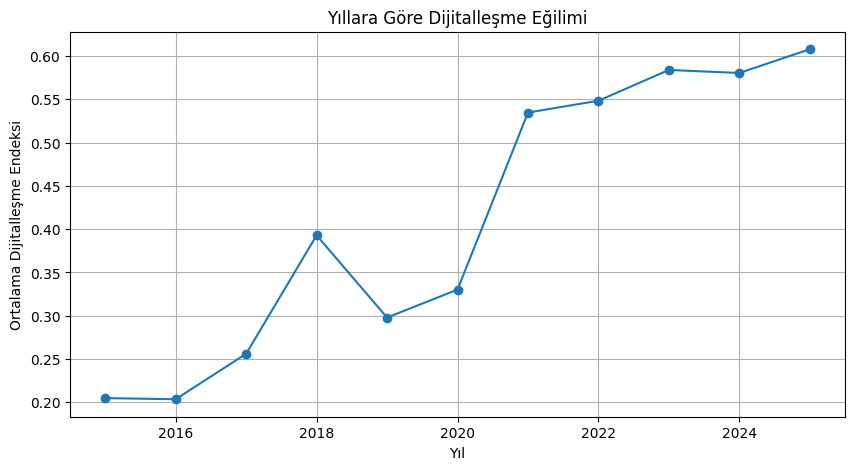

In [75]:
# ===================================================
# 1. YILLARA GÖRE DİJİTALLEŞME TRENDİ
# ===================================================

import matplotlib.pyplot as plt

yearly_index = (
    df.groupby("referans yıl")["digitalization_index"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(yearly_index["referans yıl"], yearly_index["digitalization_index"], marker="o")
plt.xlabel("Yıl")
plt.ylabel("Ortalama Dijitalleşme Endeksi")
plt.title("Yıllara Göre Dijitalleşme Eğilimi")
plt.grid(True)
plt.show()

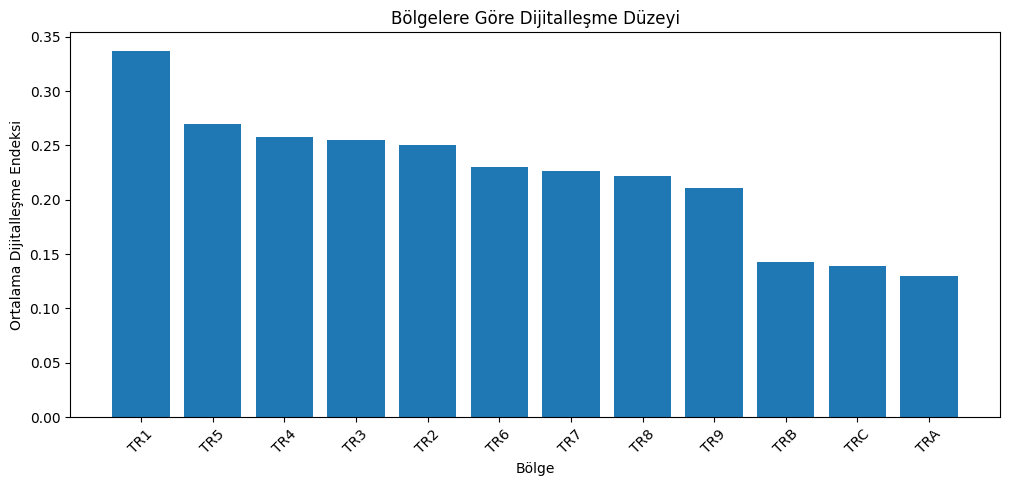

In [76]:
# ===================================================
# 2. BÖLGELERE GÖRE DİJİTALLEŞME GRAFİĞİ
# ===================================================

region_col = "istatistiki bölge birimleri sınıflaması(Düzey 1)"

regional_index = (
    df.groupby(region_col)["digitalization_index"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 5))
plt.bar(regional_index[region_col], regional_index["digitalization_index"])
plt.xlabel("Bölge")
plt.ylabel("Ortalama Dijitalleşme Endeksi")
plt.title("Bölgelere Göre Dijitalleşme Düzeyi")
plt.xticks(rotation=45)
plt.show()

In [77]:
# ===================================================
# 3. RANDOM FOREST FEATURE IMPORTANCE
# ===================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

rf_df = model_df.copy()

y = rf_df["digitalization_index"]
X = rf_df.drop(columns=["digitalization_index"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "variable": X.columns,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

print(importance_df.head(20))

                                             variable  importance
5                  education_category_İlkokul ve Altı    0.588277
2                                    age_category_60+    0.078153
1                                  age_category_46-60    0.075616
6                                          cinsiyet_2    0.044360
11                                 income_5_group_5.0    0.027240
3                       education_category_Üniversite    0.026441
7                                  çalışma durumu_3.0    0.021971
10                                 income_5_group_4.0    0.021382
0                                  age_category_31-45    0.015708
8                                  income_5_group_2.0    0.014565
9                                  income_5_group_3.0    0.014484
21  istatistiki bölge birimleri sınıflaması(Düzey ...    0.011336
22  istatistiki bölge birimleri sınıflaması(Düzey ...    0.010937
20  istatistiki bölge birimleri sınıflaması(Düzey ...    0.009726
14  istati

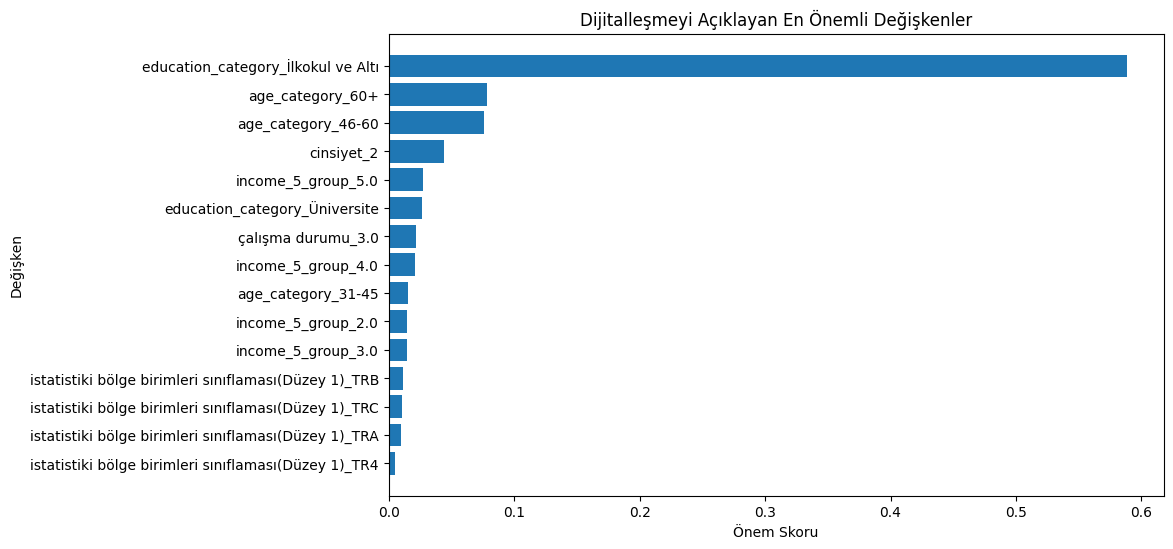

In [78]:
# ===================================================
# 4. FEATURE IMPORTANCE GRAFİĞİ
# ===================================================

top_importance = importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_importance["variable"], top_importance["importance"])
plt.xlabel("Önem Skoru")
plt.ylabel("Değişken")
plt.title("Dijitalleşmeyi Açıklayan En Önemli Değişkenler")
plt.gca().invert_yaxis()
plt.show()


In [79]:
import pandas as pd
import plotly.express as px
import plotly.io as pio

# Browserda aç
pio.renderers.default = "browser"

# ---------------------------------------------------
# BÖLGESEL ORTALAMA
# ---------------------------------------------------

region_col = "istatistiki bölge birimleri sınıflaması(Düzey 1)"

regional_index = (
    df.groupby(region_col)["digitalization_index"]
    .mean()
    .reset_index()
)

# ---------------------------------------------------
# TÜRKİYE BÖLGE KOORDİNATLARI
# ---------------------------------------------------

region_coords = {

    "TR1": [41.0, 29.0],   # İstanbul
    "TR2": [40.7, 30.5],   # Batı Marmara
    "TR3": [38.6, 27.4],   # Ege
    "TR4": [39.5, 32.5],   # Doğu Marmara
    "TR5": [39.9, 32.8],   # Batı Anadolu
    "TR6": [36.8, 34.6],   # Akdeniz
    "TR7": [39.8, 35.0],   # Orta Anadolu
    "TR8": [41.5, 33.5],   # Batı Karadeniz
    "TR9": [40.9, 38.7],   # Doğu Karadeniz
    "TRA": [39.9, 41.2],   # Kuzeydoğu Anadolu
    "TRB": [38.7, 42.0],   # Ortadoğu Anadolu
    "TRC": [37.2, 39.0]    # Güneydoğu Anadolu
}

regional_index["lat"] = regional_index[region_col].map(
    lambda x: region_coords[x][0]
)

regional_index["lon"] = regional_index[region_col].map(
    lambda x: region_coords[x][1]
)

# ---------------------------------------------------
# HARİTA
# ---------------------------------------------------

fig = px.scatter_geo(

    regional_index,

    lat="lat",
    lon="lon",

    size="digitalization_index",

    color="digitalization_index",

    hover_name=region_col,

    projection="natural earth",

    title="Türkiye Bölgesel Dijitalleşme Endeksi",

    color_continuous_scale="Viridis"
)

# Türkiye odaklı zoom

fig.update_geos(

    visible=False,

    resolution=50,

    showcountries=True,

    countrycolor="Black",

    lataxis_range=[35, 43],

    lonaxis_range=[25, 45]
)

fig.update_layout(
    width=1000,
    height=700
)

fig.show()


#veritabanına atcam verileri

In [80]:
print(df.columns.tolist())

['Unnamed: 0', 'referans yıl', 'bülten no', 'fert no', 'fert cevap durumu', 'fert durum', 'cevapsız fert', 'cevaplayan fert', 'cevaplayan fert no', 'yaş', 'cinsiyet', 'okuma yazma durumu', 'eğitim', 'çalışma durumu', 'iş sahibi mi', 'uluslararası meslek', 'işteki durumu', 'çalışmama nedeni', 'bilgisayar son kullanım zamanı', 'bilgisayar kullanım sıklığı', 'en son internet ne zaman kullanıldı', 'internet kullanım sıklığı', 'nternet kullanım yeri ev', 'internet kullanım yeri işyeri', 'internet kullanım yeri eğitim', 'internet kullanım yeri internet cafe', 'internet kullanım yeri başka ev', 'internet kullanım yeri kablosuz alan', 'internet kullanım yeri diğer', 'cep telefonu şebekesi ile internet kullanımı', 'cep telefonu kablosuz bağlantı ile internet kullanımı', 'mobil internet taşınabilir cihaz şebeke', 'taşınabilir bilgisayar ile kablosuz internet kullanımı', 'diğer cihazlar ile internet kullanımı', 'internet erişimi için cihaz kullanmıyor', 'eposta kullanımı', 'internet araması', 'so

In [81]:
mysql_df = df[
    [
        "referans yıl",
        "yaş",
        "cinsiyet",
        "education_category",
        "age_category",
        "income_5_group",
        "digitalization_index",
        "digitalization_level",
        "istatistiki bölge birimleri sınıflaması(Düzey 1)"
    ]
].copy()

mysql_df.to_csv(
    r"C:\Users\dilara\Desktop\Hane halkı bilişim tüik\ferthane\mysql_temiz_dijitallesme.csv",
    index=False,
    encoding="utf-8-sig"
)

print(mysql_df.head())
print("MySQL için temiz veri hazır.")

   referans yıl  yaş cinsiyet education_category age_category income_5_group  \
0          2015   58        1    İlkokul ve Altı        46-60            1.0   
1          2015   20        1      Ortaokul-Lise        16-30            4.0   
2          2015   48        2    İlkokul ve Altı        46-60            4.0   
3          2015   54        1      Ortaokul-Lise        46-60            4.0   
4          2015   39        2    İlkokul ve Altı        31-45            2.0   

   digitalization_index digitalization_level  \
0              0.277778                Düşük   
1              0.900000               Yüksek   
2              0.575000                 Orta   
3              0.500000                 Orta   
4              0.305556                Düşük   

  istatistiki bölge birimleri sınıflaması(Düzey 1)  
0                                              TR1  
1                                              TR1  
2                                              TR1  
3                 

In [84]:
import pandas as pd
from sqlalchemy import create_engine

# MySQL bağlantı bilgileri
user = "root"
password = "Dilara123!"
host = "localhost"
port = 3306
database = "tuik_dijitallesme_db"

# Bağlantı oluştur
engine = create_engine(
    f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}"
)

# MySQL'den tabloyu oku
sql = """
SELECT *
FROM mysql_temiz_dijitallesme;
"""

mysql_df = pd.read_sql(sql, engine)

print(mysql_df.head())
print(mysql_df.shape)

   ï»¿referans yÄ±l  yaÅŸ  cinsiyet education_category age_category  \
0              2015    58         1  Ä°lkokul ve AltÄ±        46-60   
1              2015    20         1      Ortaokul-Lise        16-30   
2              2015    48         2  Ä°lkokul ve AltÄ±        46-60   
3              2015    54         1      Ortaokul-Lise        46-60   
4              2015    39         2  Ä°lkokul ve AltÄ±        31-45   

   income_5_group  digitalization_index digitalization_level  \
0             1.0              0.277778             DÃ¼ÅŸÃ¼k   
1             4.0              0.900000              YÃ¼ksek   
2             4.0              0.575000                 Orta   
3             4.0              0.500000                 Orta   
4             2.0              0.305556             DÃ¼ÅŸÃ¼k   

  istatistiki bÃ¶lge birimleri sÄ±nÄ±flamasÄ±(DÃ¼zey 1)  
0                                                TR1     
1                                                TR1     
2             

In [91]:
mysql_df = pd.DataFrame(mysql_df)
mysql_df.tail()

,ï»¿referans yÄ±l,yaÅŸ,cinsiyet,education_category,age_category,income_5_group,digitalization_index,digitalization_level,istatistiki bÃ¶lge birimleri sÄ±nÄ±flamasÄ±(DÃ¼zey 1)
40098,2016,34,1,Ä°lkokul ve AltÄ±,31-45,1.0,0.111111,DÃ¼ÅŸÃ¼k,TR2
40099,2016,27,2,Ä°lkokul ve AltÄ±,16-30,1.0,0.000000,,TR2
40100,2016,8,1,,0-15,1.0,0.000000,,TR2
40101,2016,5,2,,0-15,1.0,0.000000,,TR2
40102,2016,3,1,,0-15,1.0,0.000000,,TR2


In [92]:
mysql_df["ï»¿referans yÄ±l"].value_counts()

ï»¿referans yÄ±l
2015    35221
2016     4882
Name: count, dtype: int64

In [93]:
print(
    df["referans yıl"].value_counts().sort_index()
)

referans yıl
2015    35850
2016    39754
2017    45591
2018    28888
2019    45060
2020    50018
2021    30530
2022    29581
2023    24771
2024    26273
2025    25493
Name: count, dtype: int64


In [94]:
import pandas as pd

df = pd.read_csv(
    "data/bütünveriler.csv",
    low_memory=False
)

print(df.shape)
df.head()

(381809, 471)


,Unnamed: 0,referans yıl,bülten no,fert no,fert cevap durumu,fert durum,cevapsız fert,cevaplayan fert,cevaplayan fert no,yaş,...,ürün güvenliği hakkında arama,yapay zeka kullanımı,yapay zeka özel amaç kullanımı,yapay zeka iş için kullanımı,yapay zeka eğitim için kullanımı,yapay zeka kullanmama nedeni,eticaretten alınan fiziksel mal,eticaret sağlık güven sorunu,kvkk reklam takip endişesi,hanehalkı adresinin kır veya kent olma durumu
0,0,2015,10011,1,1.0,CEVAPLI FERT,NaN,1.0,NaN,58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2015,10012,3,1.0,CEVAPLI FERT,NaN,1.0,NaN,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2015,10012,2,1.0,CEVAPLI FERT,NaN,1.0,NaN,48,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2015,10012,1,1.0,CEVAPLI FERT,NaN,1.0,NaN,54,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2015,10013,3,1.0,CEVAPLI FERT,NaN,1.0,NaN,39,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
mysql_df[]

In [ ]:
"ï»¿referans yÄ±l"

SyntaxError: invalid character '»' (U+00BB) (4117396582.py, line 1)